# Setting up kaggle and downloading the data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
! mkdir ~/.kaggle

In [ ]:
!cp /content/drive/MyDrive/ColabNotebooks/kaggle_API_credentials/kaggle.json ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download walmart-recruiting-store-sales-forecasting

100% 2.70M/2.70M [00:00<00:00, 168MB/s]



In [ ]:
! unzip /content/walmart-recruiting-store-sales-forecasting.zip


Archive:  /content/walmart-recruiting-store-sales-forecasting.zip
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           


In [ ]:
! unzip /content/walmart-recruiting-store-sales-forecasting.zip
! unzip /content/train.csv.zip
! unzip /content/test.csv.zip
! unzip /content/features.csv.zip
! unzip /content/stores.csv.zip

Archive:  /content/walmart-recruiting-store-sales-forecasting.zip
replace features.csv.zip? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: features.csv.zip        
  inflating: sampleSubmission.csv.zip  
  inflating: stores.csv              
  inflating: test.csv.zip            
  inflating: train.csv.zip           
Archive:  /content/train.csv.zip
  inflating: train.csv               
Archive:  /content/test.csv.zip
  inflating: test.csv                
Archive:  /content/features.csv.zip
  inflating: features.csv            
unzip:  cannot find or open /content/stores.csv.zip, /content/stores.csv.zip.zip or /content/stores.csv.zip.ZIP.


# Import libraries

In [ ]:
import torch
from torch import nn
from torch.optim import Adam
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split
import wandb
import torch.nn as nn
import torch.nn.functional as F
from torchsummary import summary
from torchvision import transforms
import torchvision.models as models
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_regression
import missingno as msno



device = "cuda" if torch.cuda.is_available() else "cpu" # detect the GPU if any, if not use CPU
print("Device available: ", device)

Device available:  cpu


# load data

In [ ]:
train = pd.read_csv('train.csv')
stores = pd.read_csv('stores.csv')
features = pd.read_csv('features.csv')

df = pd.merge(train, stores, on='Store', how='left')
df = pd.merge(df, features, on=['Store', 'Date', 'IsHoliday'], how='left')

df['Date'] = pd.to_datetime(df['Date'])
print(df.head())

   Store  Dept       Date  Weekly_Sales  IsHoliday Type    Size  Temperature  \
0      1     1 2010-02-05      24924.50      False    A  151315        42.31   
1      1     1 2010-02-12      46039.49       True    A  151315        38.51   
2      1     1 2010-02-19      41595.55      False    A  151315        39.93   
3      1     1 2010-02-26      19403.54      False    A  151315        46.63   
4      1     1 2010-03-05      21827.90      False    A  151315        46.50   

   Fuel_Price  MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
0       2.572        NaN        NaN        NaN        NaN        NaN   
1       2.548        NaN        NaN        NaN        NaN        NaN   
2       2.514        NaN        NaN        NaN        NaN        NaN   
3       2.561        NaN        NaN        NaN        NaN        NaN   
4       2.625        NaN        NaN        NaN        NaN        NaN   

          CPI  Unemployment  
0  211.096358         8.106  
1  211.242170         8.10

In [ ]:
print(train.columns)
print(stores.columns)
print(features.columns)
print(df.columns)

Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday'], dtype='object')
Index(['Store', 'Type', 'Size'], dtype='object')
Index(['Store', 'Date', 'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2',
       'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment',
       'IsHoliday'],
      dtype='object')
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'IsHoliday', 'Type', 'Size',
       'Temperature', 'Fuel_Price', 'MarkDown1', 'MarkDown2', 'MarkDown3',
       'MarkDown4', 'MarkDown5', 'CPI', 'Unemployment'],
      dtype='object')


In [ ]:
column = 'Store'
print(f"Possible values for '{column}': {df[column].unique()}")


column = 'Date'
print(f"Possible values for '{column}': {df[column].unique()}")


column = 'Dept'
print(f"Possible values for '{column}': {df[column].unique()}")

column = 'Type'
print(f"Possible values for '{column}': {df[column].unique()}")

column = 'MarkDown1'
print(f"Possible values for '{column}': {df[column].unique()}")
column = 'MarkDown2'
print(f"Possible values for '{column}': {df[column].unique()}")
column = 'MarkDown3'
print(f"Possible values for '{column}': {df[column].unique()}")
column = 'MarkDown4'
print(f"Possible values for '{column}': {df[column].unique()}")
column = 'MarkDown5'
print(f"Possible values for '{column}': {df[column].unique()}")

column = 'IsHoliday'
print(f"Possible values for '{column}': {df[column].unique()}")


Possible values for 'Store': [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45]
Possible values for 'Date': <DatetimeArray>
['2010-02-05 00:00:00', '2010-02-12 00:00:00', '2010-02-19 00:00:00',
 '2010-02-26 00:00:00', '2010-03-05 00:00:00', '2010-03-12 00:00:00',
 '2010-03-19 00:00:00', '2010-03-26 00:00:00', '2010-04-02 00:00:00',
 '2010-04-09 00:00:00',
 ...
 '2012-08-24 00:00:00', '2012-08-31 00:00:00', '2012-09-07 00:00:00',
 '2012-09-14 00:00:00', '2012-09-21 00:00:00', '2012-09-28 00:00:00',
 '2012-10-05 00:00:00', '2012-10-12 00:00:00', '2012-10-19 00:00:00',
 '2012-10-26 00:00:00']
Length: 143, dtype: datetime64[ns]
Possible values for 'Dept': [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 16 17 18 19 20 21 22 23 24 25
 26 27 28 29 30 31 32 33 34 35 36 37 38 40 41 42 44 45 46 47 48 49 51 52
 54 55 56 58 59 60 67 71 72 74 77 78 79 80 81 82 83 85 87 90 91 92 93 94
 95 96 97 98 99 39 50 43 65]
Possi

In [ ]:
test = pd.read_csv('test.csv')
print(test.head())
print(test.columns)

column = 'Date'
print(f"Possible values for '{column}': {test[column].unique()}")


   Store  Dept        Date  IsHoliday
0      1     1  2012-11-02      False
1      1     1  2012-11-09      False
2      1     1  2012-11-16      False
3      1     1  2012-11-23       True
4      1     1  2012-11-30      False
Index(['Store', 'Dept', 'Date', 'IsHoliday'], dtype='object')
Possible values for 'Date': ['2012-11-02' '2012-11-09' '2012-11-16' '2012-11-23' '2012-11-30'
 '2012-12-07' '2012-12-14' '2012-12-21' '2012-12-28' '2013-01-04'
 '2013-01-11' '2013-01-18' '2013-01-25' '2013-02-01' '2013-02-08'
 '2013-02-15' '2013-02-22' '2013-03-01' '2013-03-08' '2013-03-15'
 '2013-03-22' '2013-03-29' '2013-04-05' '2013-04-12' '2013-04-19'
 '2013-04-26' '2013-05-03' '2013-05-10' '2013-05-17' '2013-05-24'
 '2013-05-31' '2013-06-07' '2013-06-14' '2013-06-21' '2013-06-28'
 '2013-07-05' '2013-07-12' '2013-07-19' '2013-07-26']


  we have to predict 39 weeks with 143 weeks of data. so a good train/val = total train/test = (train +val)/test => train = 112 val = 31

# average sales for each (store,dept)

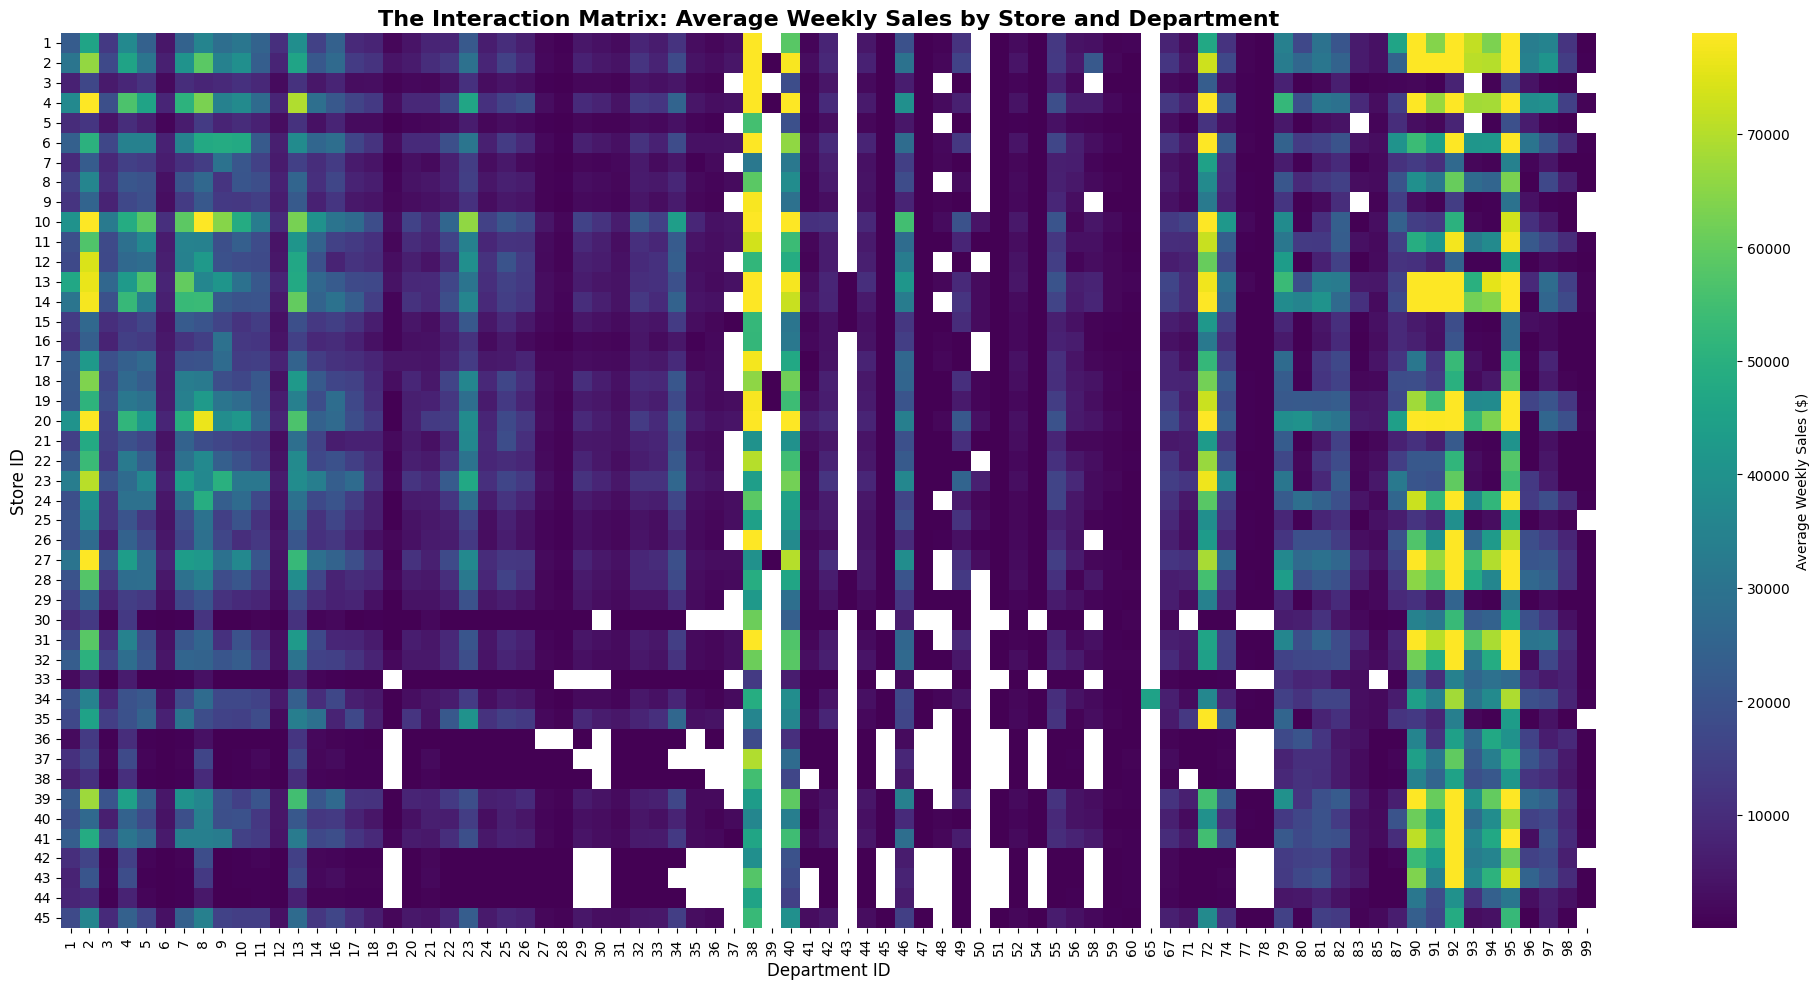

In [ ]:

store_dept_pivot = train.pivot_table(
    values='Weekly_Sales',
    index='Store',
    columns='Dept',
    aggfunc='mean'
)

plt.figure(figsize=(20, 10))
sns.heatmap(store_dept_pivot, cmap='viridis', robust=True, cbar_kws={'label': 'Average Weekly Sales ($)'})

plt.title('The Interaction Matrix: Average Weekly Sales by Store and Department', fontsize=16, fontweight='bold')
plt.xlabel('Department ID', fontsize=12)
plt.ylabel('Store ID', fontsize=12)
plt.tight_layout()
plt.show()

# total sales by time

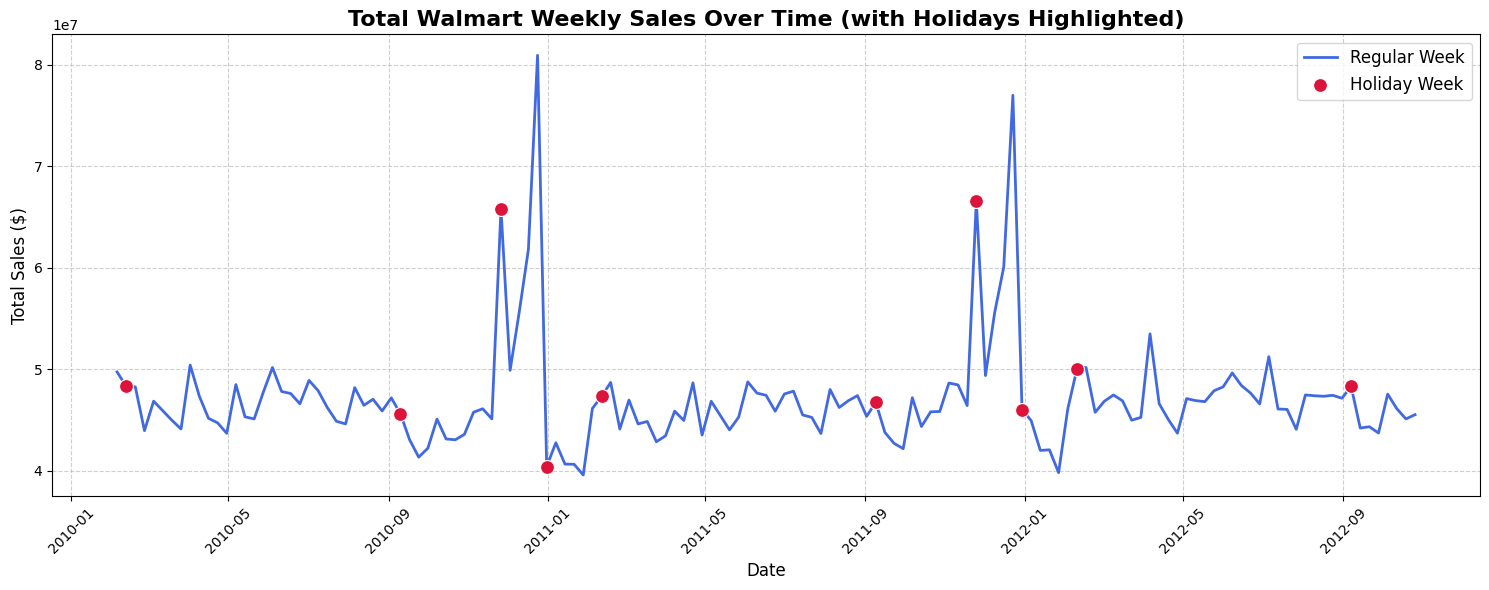

In [ ]:

weekly_sales = df.groupby('Date').agg({
    'Weekly_Sales': 'sum',
    'IsHoliday': 'max'
}).reset_index()

holiday_weeks = weekly_sales[weekly_sales['IsHoliday'] == True]

plt.figure(figsize=(15, 6))

sns.lineplot(data=weekly_sales, x='Date', y='Weekly_Sales', color='royalblue', label='Regular Week', linewidth=2)

sns.scatterplot(data=holiday_weeks, x='Date', y='Weekly_Sales', color='crimson', label='Holiday Week', s=100, zorder=5)

plt.title('Total Walmart Weekly Sales Over Time (with Holidays Highlighted)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# individual store sales by time

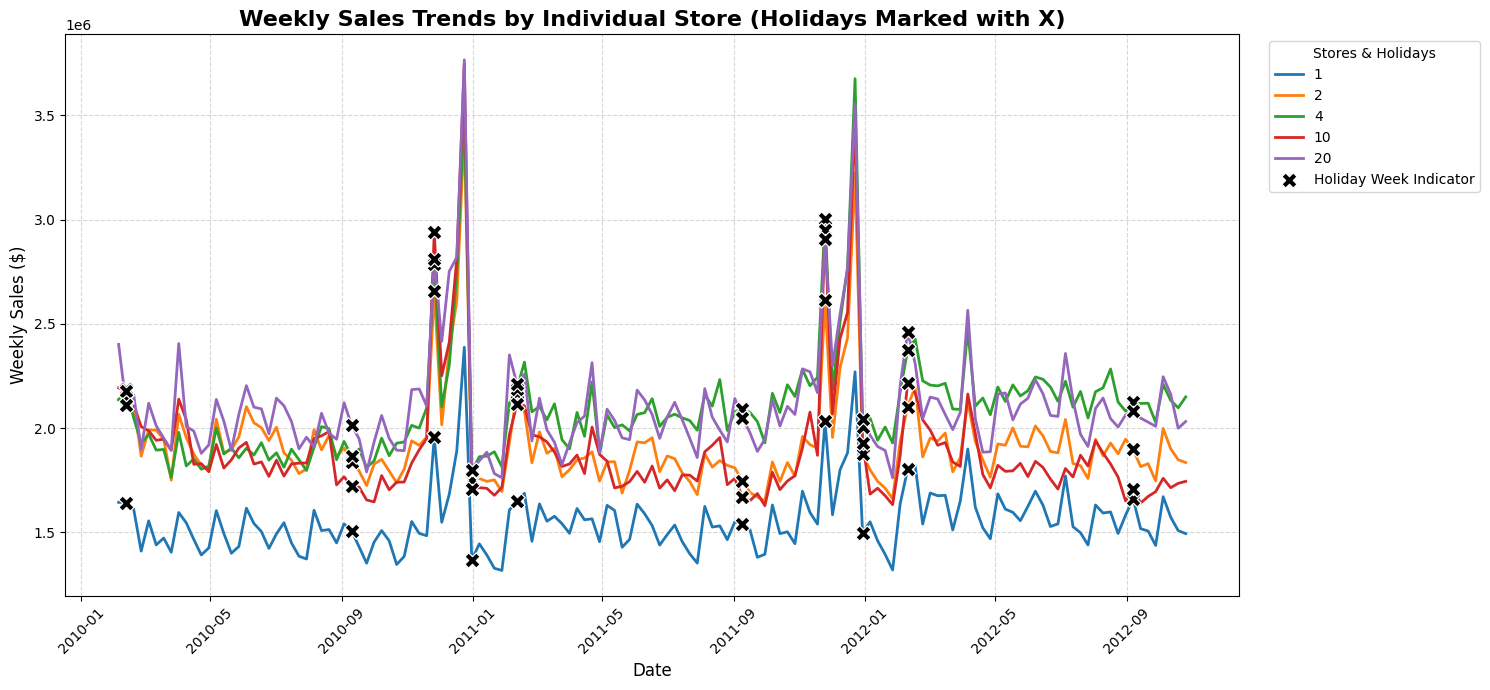

In [ ]:

store_sales = df.groupby(['Store', 'Date']).agg({
    'Weekly_Sales': 'sum',
    'IsHoliday': 'max'
}).reset_index()

store_sales['Store'] = store_sales['Store'].astype(str)

some_stores = ['1', '2', '4', '10', '20']
store_sales = store_sales[store_sales['Store'].isin(some_stores)]

holiday_weeks = store_sales[store_sales['IsHoliday'] == True]

plt.figure(figsize=(15, 7))

sns.lineplot(
    data=store_sales,
    x='Date',
    y='Weekly_Sales',
    hue='Store',
    palette='tab10',
    linewidth=2
)

sns.scatterplot(
    data=holiday_weeks,
    x='Date',
    y='Weekly_Sales',
    color='black',
    marker='X',
    s=120,
    label='Holiday Week Indicator',
    zorder=5
)

plt.title('Weekly Sales Trends by Individual Store (Holidays Marked with X)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Weekly Sales ($)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title='Stores & Holidays')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# correlation and MI with each variable

--- Correlation with Weekly_Sales ---
Size            0.243828
Dept            0.148032
MarkDown5       0.090362
MarkDown1       0.085251
MarkDown3       0.060385
MarkDown4       0.045414
MarkDown2       0.024130
IsHoliday       0.012774
Fuel_Price     -0.000120
Temperature    -0.002312
CPI            -0.020921
Unemployment   -0.025864
Store          -0.085195
Name: Weekly_Sales, dtype: float64
-------------------------------------


/tmp/ipykernel_588/2167176115.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sales_corr.values, y=sales_corr.index, palette='viridis')


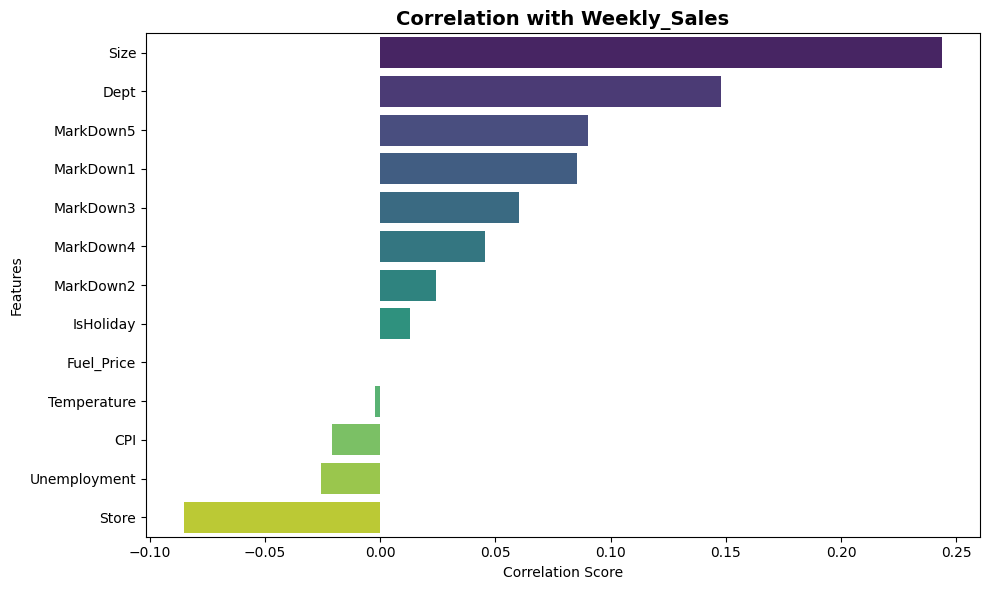

In [ ]:
df['IsHoliday'] = df['IsHoliday'].astype(int)
numeric_df = df.select_dtypes(include=[np.number])

sales_corr = numeric_df.corr()['Weekly_Sales'].sort_values(ascending=False)
sales_corr = sales_corr.drop('Weekly_Sales')

print("--- Correlation with Weekly_Sales ---")
print(sales_corr)
print("-------------------------------------")


plt.figure(figsize=(10, 6))
sns.barplot(x=sales_corr.values, y=sales_corr.index, palette='viridis')
plt.title('Correlation with Weekly_Sales', fontsize=14, fontweight='bold')
plt.xlabel('Correlation Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


--- Mutual information with Weekly_Sales ---
Dept            0.855450
Store           0.168586
Size            0.153478
Unemployment    0.093608
Type_C          0.044800
Type_A          0.031177
CPI             0.028713
MarkDown1       0.021003
Type_B          0.020194
Temperature     0.019746
MarkDown5       0.019176
Fuel_Price      0.013595
MarkDown3       0.010725
MarkDown4       0.009557
MarkDown2       0.005824
IsHoliday       0.000458
Name: MI Scores, dtype: float64
-------------------------------------


/tmp/ipykernel_588/1264836069.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mi_scores.values, y=mi_scores.index, palette='viridis')


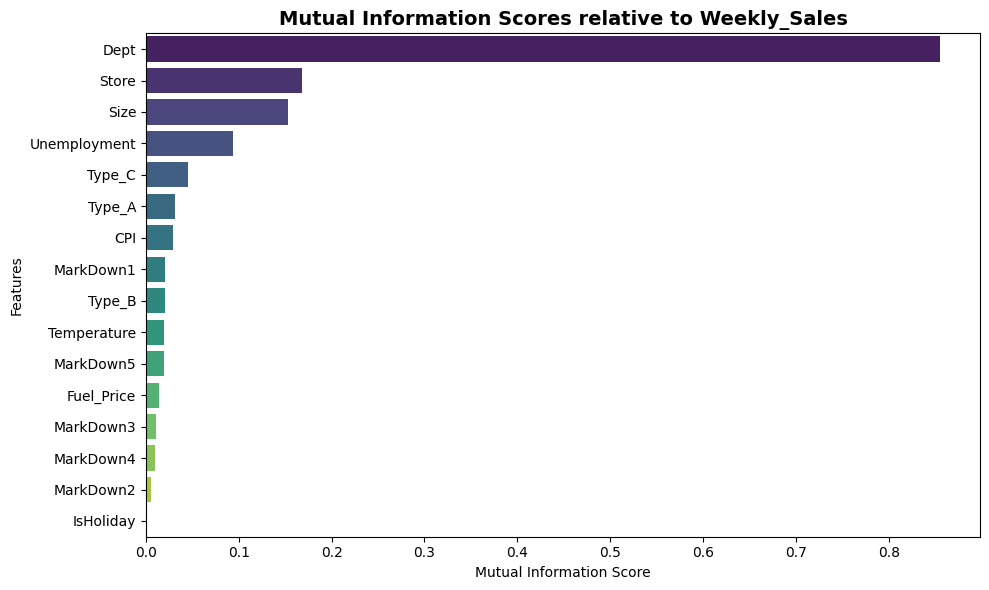

In [ ]:
mi_df = df.drop(columns=['Date']).copy()
mi_df = mi_df.fillna(0)

if 'Type' in mi_df.columns:
    mi_df = pd.get_dummies(mi_df, columns=['Type'], dtype=int)

X = mi_df.drop(columns=['Weekly_Sales'])
y = mi_df['Weekly_Sales']
mi_scores = mutual_info_regression(X, y, random_state=42)
mi_scores = pd.Series(mi_scores, name="MI Scores", index=X.columns)
mi_scores = mi_scores.sort_values(ascending=False)

print("--- Mutual information with Weekly_Sales ---")
print(mi_scores)
print("-------------------------------------")

plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores.values, y=mi_scores.index, palette='viridis')
plt.title('Mutual Information Scores relative to Weekly_Sales', fontsize=14, fontweight='bold')
plt.xlabel('Mutual Information Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# let's see how much data is missing

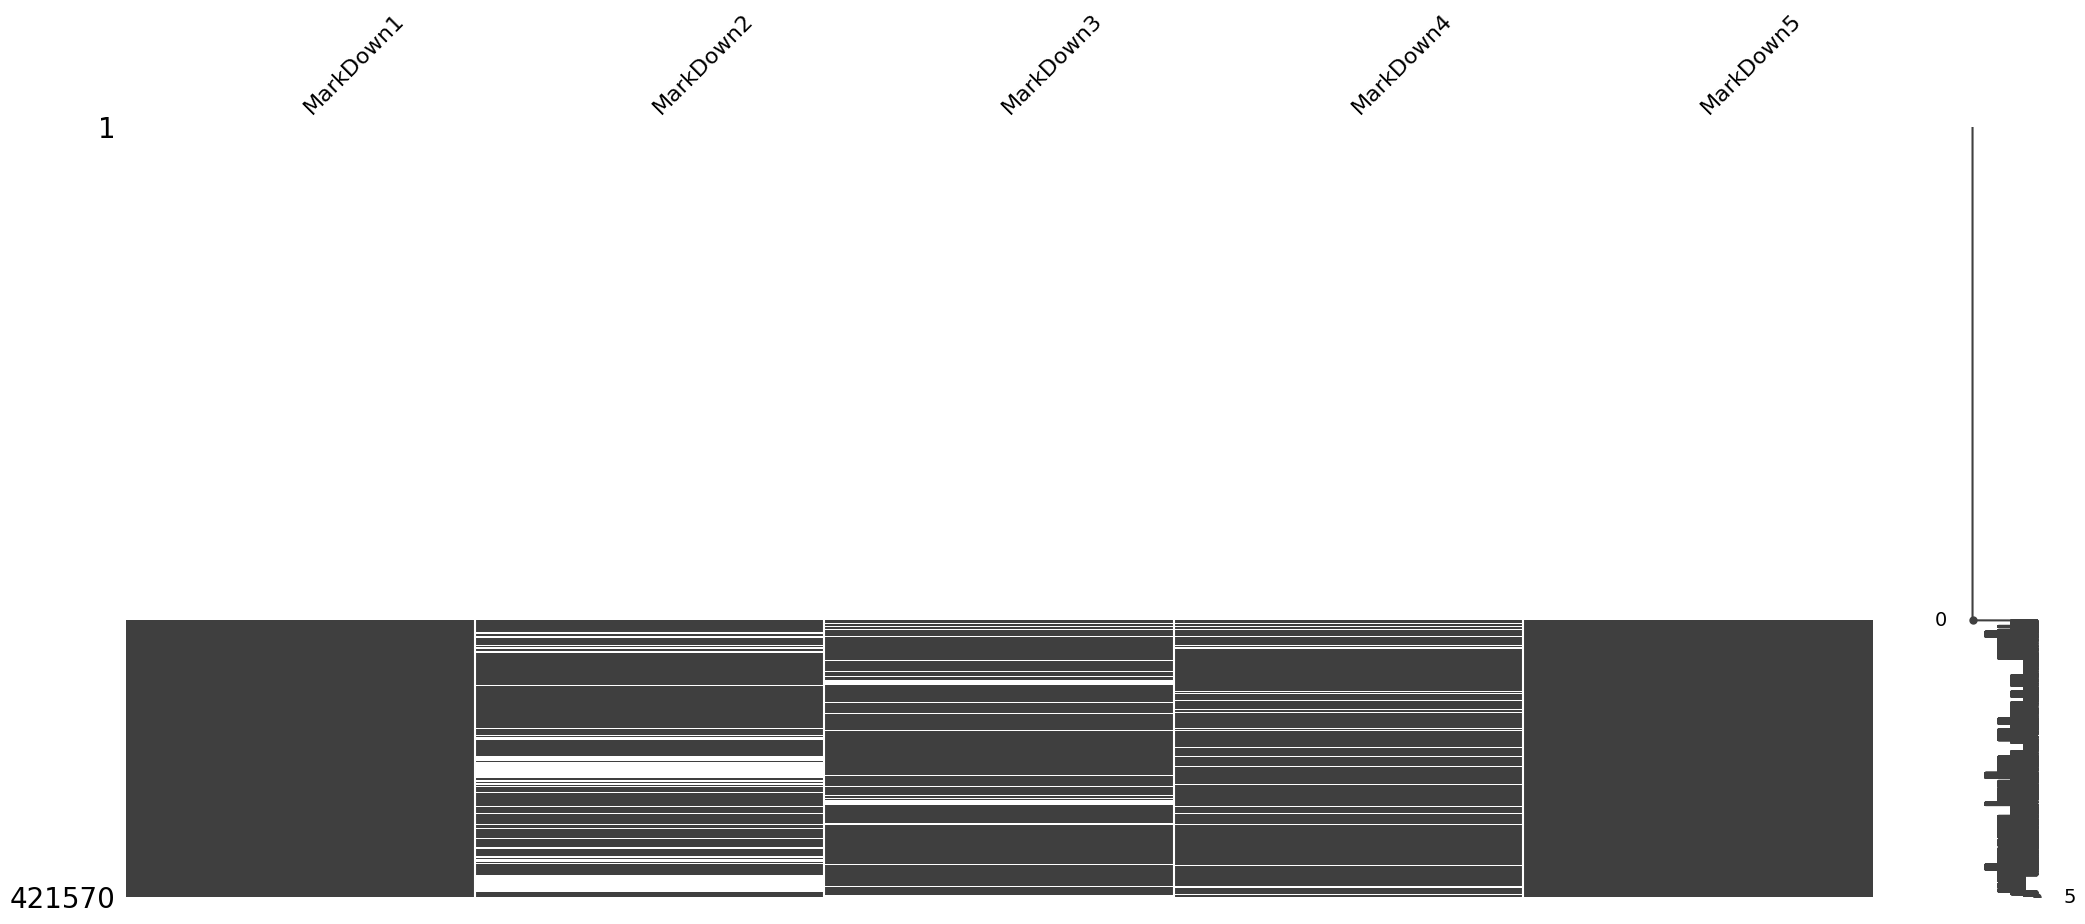

In [ ]:
df_sorted = df.sort_values('Date')
msno.matrix(df_sorted[['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']])
plt.show()

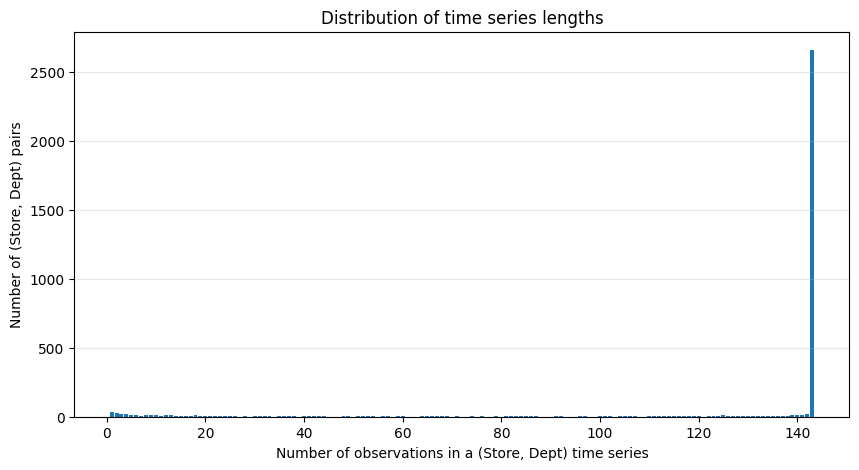

In [ ]:
series_lengths = (
    train
    .groupby(['Store', 'Dept'])
    .size()
    .reset_index(name='num_observations')
)

length_distribution = (
    series_lengths['num_observations']
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))
plt.bar(length_distribution.index, length_distribution.values, width=0.8)

plt.xlabel("Number of observations in a (Store, Dept) time series")
plt.ylabel("Number of (Store, Dept) pairs")
plt.title("Distribution of time series lengths")
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
display(length_distribution.rename("Number of (Store, Dept) pairs"))

,"Number of (Store, Dept) pairs"
num_observations,
1,37
2,30
3,19
4,18
5,14
...,...
139,11
140,11
141,15


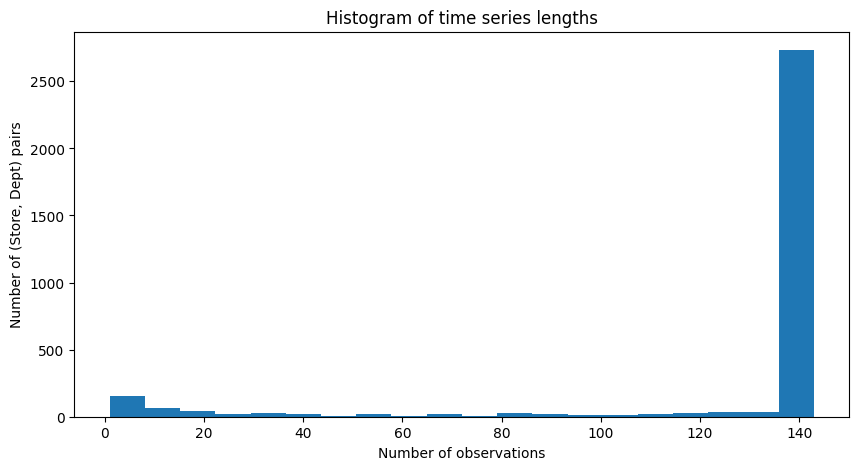

In [ ]:
plt.figure(figsize=(10, 5))
plt.hist(series_lengths['num_observations'], bins=20)

plt.xlabel("Number of observations")
plt.ylabel("Number of (Store, Dept) pairs")
plt.title("Histogram of time series lengths")

plt.show()